# Pyro Model for ODMR Spectra Fitting

This notebook builds a Pyro model to fit ODMR spectra using the `NV_ODMR` model from `odmrsimulator.py`.
The model optimizes the following parameters:
- E_rad_s: strain parameter (rad/s)
- D0: zero-field splitting at T0 (MHz)
- alpha: temperature coefficient for D (MHz/K)
- rabi_rate: Rabi frequency (MHz)
- amp: amplitude scaling factor (scales the dip depth to match experimental contrast)

Fixed parameters (using defaults from odmrsimulator.py):
- T1_0: 1e6 us
- T2_0: 1e3 us
- beta: 0.01 1/K
- gamma: 0.005 1/K
- T0: 300.0 K

we set D0 to be 2877.0 MHz and allow a 1 MHz wiggle around it. Basically we are incorporating any non-linearities in the temperature dependence into the theoretically derived, temp independent, D field energy term

In [60]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS, HMC
from pyro.infer.autoguide import init_to_value
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import importlib
from sklearn.preprocessing import MinMaxScaler

# Import the ODMR simulator
import odmrsimulator
import helper
importlib.reload(odmrsimulator)

torch.set_default_dtype(torch.float64)

## Pyro Model

The model directly calls `NV_ODMR` from `odmrsimulator.py` and handles tensor conversions inline.

## Pyro Model

The model samples parameters from priors and directly calls NV_ODMR to generate predictions.

In [61]:
def model(data):
    """
    Pyro model for ODMR spectra fitting.
    
    Parameters:
    -----------
    data : tuple
        (RF_freq, T, y_obs) where:
        - RF_freq: array of RF frequencies (MHz)
        - T: temperature (K)
        - y_obs: observed PL values
    
    Note: BNV (magnetic field) is fixed at 0.0 Gauss (default from odmrsimulator.py)
    """
    # Unpack data tuple
    RF_freq, T, y_obs = data
    
    # Convert inputs to tensors if needed
    if isinstance(RF_freq, torch.Tensor):
        RF_freq_np = RF_freq.detach().cpu().numpy()
    else:
        RF_freq_np = np.asarray(RF_freq)
    
    
    # Convert y_obs to tensor - handle various input types
    if isinstance(y_obs, torch.Tensor):
        y_obs = y_obs.double()
    elif isinstance(y_obs, np.ndarray):
        y_obs = torch.tensor(y_obs, dtype=torch.float64)
    elif isinstance(y_obs, (list, tuple)):
        # If it's still a tuple/list after extraction, handle it
        if len(y_obs) > 0 and isinstance(y_obs[0], torch.Tensor):
            # List/tuple of tensors - take the first one
            if len(y_obs) == 1:
                y_obs = y_obs[0].double()
            else:
                # Multiple elements - take the last one (should be y_obs)
                y_obs = y_obs[-1].double() if isinstance(y_obs[-1], torch.Tensor) else torch.tensor(np.asarray(y_obs), dtype=torch.float64)
        else:
            # Regular list/tuple of numbers - convert via numpy
            y_obs = torch.tensor(np.asarray(y_obs, dtype=np.float64), dtype=torch.float64)
    else:
        # Try to convert via numpy first
        try:
            y_obs = torch.tensor(np.asarray(y_obs, dtype=np.float64), dtype=torch.float64)
        except (ValueError, TypeError) as e:
            raise ValueError(
                f"Cannot convert y_obs to tensor. y_obs type: {type(y_obs)}, "
                f"y_obs value: {y_obs}. Error: {e}"
            )
    
    # Ensure T is a scalar (squeeze if needed)
    if isinstance(T, torch.Tensor):
        T = T.squeeze()
        if T.numel() != 1:
            raise ValueError(f"T must be a scalar, got tensor with shape {T.shape}")
    
    # Ensure 1D
    RF_freq_np = RF_freq_np.flatten()
    y_obs = y_obs.flatten()
    n_data = len(y_obs)
    
    # Sample parameters from priors (only free parameters)
    E_rad_s = pyro.sample("E_rad_s", dist.Normal(3.14 * 4 * 1e6, 10e6)).double()
    D0 = pyro.sample("D0", dist.Normal(2877.0, 1.0)).double()
    alpha = pyro.sample("alpha", dist.Normal(-0.075, 0.05)).double()
    rabi_rate = pyro.sample("rabi_rate", dist.Normal(1.5, 0.05)).double()
    amp = pyro.sample("amp", dist.LogNormal(np.log(0.05), 0.5)).double()  # dip depth scaling
    
    # Sample noise variance
    var = pyro.sample("var", dist.HalfNormal(scale=0.1)).double()

     
    # Set module-level parameters (read by D_of_T, T1_of_T, T2_of_T)
    odmrsimulator.D0 = D0
    odmrsimulator.alpha = alpha
    # odmrsimulator.T1_0 = T1_0_val
    # odmrsimulator.beta = beta_val
    # odmrsimulator.T2_0 = T2_0_val
    # odmrsimulator.gamma = gamma_val
    odmrsimulator.E_rad_s = E_rad_s
    # odmrsimulator.B = BNV_val
    odmrsimulator.rabi_rate = rabi_rate
    
    # Calculate PL for each frequency using direct NV_ODMR call
    PL_values = np.zeros(n_data, dtype=np.float64)
    for i, RF_freq_val in enumerate(RF_freq_np):
        PL_values[i] = odmrsimulator.NV_ODMR(RF_freq_val, rabi_rate, T_, E_rad_s_param=E_rad_s)

    # Normalize to baseline of 1 (off-resonance max = 1)
    PL_max = PL_values.max()
    if PL_max > 0:
        PL_norm = PL_values / PL_max  # baseline = 1, dips go toward 0
    else:
        PL_norm = PL_values

    # Scale the dip depth with amp: baseline stays at 1, dip depth is controlled by amp
    PL_scaled = 1.0 - amp.item() * (1.0 - PL_norm)

    # Convert to tensor
    PL_pred = torch.tensor(PL_scaled, dtype=torch.float64)
    
    # Sample observations
    with pyro.plate("data", n_data):
        pyro.sample("obs", dist.Normal(PL_pred, var), obs=y_obs)
    
    return PL_pred

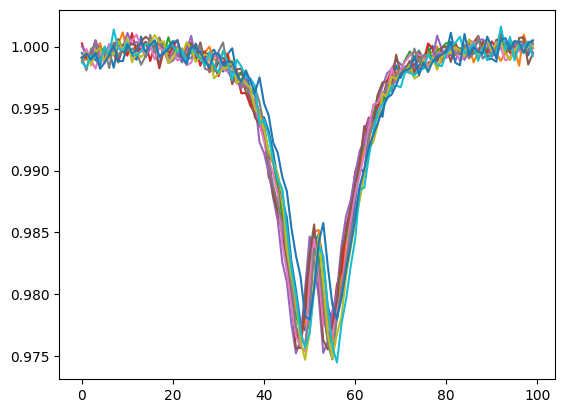

In [62]:
## import data file
fpath = './cycle1'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, 1:-1]
df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', '-20'], inplace= True)
df.iloc[:, 2:].plot(legend= False); plt.show()

# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr = df.iloc[:, 1:7]


In [63]:
# this will be the data we'll start with, shown as red circles
def dataslicer(x, y, col1 =0 ,col2=1):
    x_scale_tensor = torch.tensor(x_scale).double()
    # squeeze the selected column to produce a 1-D tensor (N,) instead of (N,1)
    y_vals = y_esr.iloc[:, col1:col2].values.squeeze()
    y_scale_tensor = torch.tensor(y_vals).double()
    return x_scale_tensor, y_scale_tensor

In [64]:
RF_freq = np.linspace(2850, 2950, 100)

In [65]:
x_obs, y_obs = dataslicer(x_scale, y_esr, col1=0, col2=1)
T_ = 273.15 + 25.0  # Example temperature in Kelvin

data_ = (RF_freq, T_, (x_obs.clone().detach().double(), y_obs.clone().detach().double()))
data = data_[2]

In [66]:



# Convert to tensors
RF_freq_tensor = torch.tensor(RF_freq, dtype=torch.float64)  # or use your frequency array
T_tensor = torch.tensor(300.0, dtype=torch.float64)  # temperature in Kelvin
y_obs_tensor = y_obs  # PL values



## Run MCMC Inference

Use NUTS sampler for Bayesian inference.

In [ ]:
# Set initial values (only for free parameters)
init_vals = {
    "E_rad_s": torch.tensor(1e6),
    "D0": torch.tensor(2877.),
    "alpha": torch.tensor(0.072),
    "rabi_rate": torch.tensor(1.5),
    "amp": torch.tensor(0.05),
    "var": torch.tensor(0.01**2),
}

# Create NUTS kernel
kernel = NUTS(
    model, 
    jit_compile=False,  # Set to False due to numpy/qutip dependencies
    init_strategy=init_to_value(values=init_vals),
    max_tree_depth=3,
    ignore_jit_warnings=True
)

# Run MCMC
# Note: num_samples must be > 0 to collect samples after warmup
mcmc = MCMC(kernel, num_samples=1, warmup_steps=1, num_chains=1)
mcmc.run(data_)

# Get samples
samples = mcmc.get_samples()

Warmup:   0%|          | 0/2 [00:00, ?it/s]/Users/zeeshanahmed/pyro/quantum/lib/python3.11/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


## Analyze Results

Extract posterior statistics and visualize results.

In [ ]:
# Print posterior statistics
print("Posterior Statistics:")
print("=" * 50)
for param_name in ["E_rad_s", "D0", "alpha", "rabi_rate", "amp"]:
    param_samples = samples[param_name].detach().cpu().numpy()
    mean_val = param_samples.mean()
    std_val = param_samples.std()
    print(f"{param_name:12s}: {mean_val:12.4e} ± {std_val:12.4e}")

print("\nFixed Parameters (defaults from odmrsimulator.py):")
print("=" * 50)
print(f"{'T1_0':12s}: {1e6:12.4e}")
print(f"{'T2_0':12s}: {1e3:12.4e}")
print(f"{'beta':12s}: {0.01:12.4e}")
print(f"{'gamma':12s}: {0.005:12.4e}")
print(f"{'T0':12s}: {300.0:12.4e}")
print(f"{'B':12s}: {0.0:12.4e}")


In [ ]:
# Generate predictions using posterior mean parameters
posterior_means = {}
for param_name in ["E_rad_s", "D0", "alpha", "rabi_rate", "amp"]:
    posterior_means[param_name] = samples[param_name].mean().item()

# Extract data from the data tuple (now: RF_freq, T, y_obs)
RF_freq_data, T_data, y_obs_data = data_
# Handle case where y_obs might be a tuple
if isinstance(y_obs_data, tuple) and len(y_obs_data) == 2:
    y_obs_data = y_obs_data[1]

# Convert to numpy for plotting
if isinstance(RF_freq_data, torch.Tensor):
    RF_freq = RF_freq_data.detach().cpu().numpy()
else:
    RF_freq = np.asarray(RF_freq_data)

if isinstance(y_obs_data, torch.Tensor):
    y_obs = y_obs_data.detach().cpu().numpy()
else:
    y_obs = np.asarray(y_obs_data)

# Get T value
T_val = T_data.item() if isinstance(T_data, torch.Tensor) else float(T_data)

# Use default values for fixed parameters
BNV_val = 0.0  # Default magnetic field
T0_val = 300.0  # Default reference temperature
T1_0_val = 1e6  # Default T1 at T0
T2_0_val = 1e3  # Default T2 at T0
beta_val = 0.01  # Default T1 temperature coefficient
gamma_val = 0.005  # Default T2 temperature coefficient

# Generate predictions using posterior mean parameters
# Set module-level parameters
odmrsimulator.D0 = posterior_means["D0"]
odmrsimulator.T0 = T0_val
odmrsimulator.alpha = posterior_means["alpha"]
odmrsimulator.T1_0 = T1_0_val
odmrsimulator.beta = beta_val
odmrsimulator.T2_0 = T2_0_val
odmrsimulator.gamma = gamma_val
odmrsimulator.E_rad_s = posterior_means["E_rad_s"]
odmrsimulator.B = BNV_val

# Calculate PL predictions
PL_raw = np.zeros(len(RF_freq), dtype=np.float64)
for i, RF_freq_val in enumerate(RF_freq):
    PL_raw[i] = odmrsimulator.NV_ODMR(
        BNV_val, RF_freq_val, posterior_means["rabi_rate"], 
        T_val, E_rad_s_param=posterior_means["E_rad_s"]
    )

# Normalize to baseline of 1, then scale dip depth with amp
PL_max = PL_raw.max()
if PL_max > 0:
    PL_norm = PL_raw / PL_max
else:
    PL_norm = PL_raw
amp_val = posterior_means["amp"]
PL_pred_mean = 1.0 - amp_val * (1.0 - PL_norm)

# Plot results
plt.figure(figsize=(12, 5))

# Plot 1: Data and fit
plt.subplot(1, 2, 1)
plt.plot(RF_freq, y_obs, 'r.', label='Observed PL', alpha=0.5, markersize=3)
plt.plot(RF_freq, PL_pred_mean, 'g-', label='Posterior Mean Fit', linewidth=2)
plt.xlabel('RF Frequency (MHz)')
plt.ylabel('PL (a.u.)')
plt.title('ODMR Spectra Fit')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Residuals
plt.subplot(1, 2, 2)
residuals = y_obs - PL_pred_mean
plt.plot(RF_freq, residuals, 'k.', alpha=0.5, markersize=3)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('RF Frequency (MHz)')
plt.ylabel('Residuals')
plt.title('Residuals')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Plot posterior distributions
param_names = ["E_rad_s", "D0", "alpha", "rabi_rate", "amp"]
n_params = len(param_names)
n_cols = 4
n_rows = (n_params + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten() if n_params > 1 else [axes]

# Check if true_vals exists (for synthetic data)
try:
    true_vals_dict = true_vals
except NameError:
    true_vals_dict = None

for i, param_name in enumerate(param_names):
    param_samples = samples[param_name].detach().cpu().numpy()
    axes[i].hist(param_samples, bins=50, alpha=0.7, edgecolor='black')
    
    # Plot true value if available
    if true_vals_dict is not None and param_name in true_vals_dict:
        axes[i].axvline(true_vals_dict[param_name], color='r', linestyle='--', linewidth=2, label='True')
    
    # Plot posterior mean
    axes[i].axvline(param_samples.mean(), color='g', linestyle='--', linewidth=2, label='Posterior Mean')
    axes[i].set_xlabel(param_name)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

# Remove extra subplots
for i in range(n_params, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()